## Concept 1: Merging Multiple CSVs into One DataFrame
easier to analyse one giant dataset 
use Python's built-in os library to list all the files in a folder, and pandas' pd.concat() function to stitch them together

In [124]:
import pandas as pd
import os

####  1. Create an empty DataFrame to hold everything

In [125]:
all_months_data = pd.DataFrame()

####  2. Get a list of all files in the directory

In [126]:
files = [file for file in os.listdir('./Sales_data')]

#### 3. Loop through the files, read them, and append to the main DataFrame

In [127]:
# The 'for' loop must be inside the code cell!
for file in files:
    df = pd.read_csv('./Sales_data/' + file)
    all_months_data = pd.concat([all_months_data, df])

#### Save the merged data to a new CSV so you don't have to run this loop again

In [128]:
all_months_data.to_csv('all_data.csv', index=False)

## Concept 2: Creating New Columns via String Slicing
#### To find out which month had the most sales, we need a specific "Month" column. Right now, the month is hidden inside the "Order Date" string (e.g., "04/19/19"). Because dates are currently formatted as strings (text), we can grab the first two characters of the string using .str[0:2]

In [129]:
all_data = pd.read_csv('all_data.csv')
all_data['Month'] = all_data['Order Date'].str[0:2]

In [130]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",05
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",05
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",05
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",05
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",05


## Concept 3: Filtering and Cleaning "Bad" Data
Now that we have a Month column containing strings like '04', we want to cast it to an integer data type so we can work with it mathematically
However, running all_data['Month'].astype('int32') will crash for two reasons found in our data
NaN rows: There are completely blank rows causing errors
Duplicate Headers: Because we stitched 12 files together, the column headers (like "Order Date") were occasionally copied in as rows of data. When pandas grabbed the first two characters of "Order Date", it grabbed 'Or'. Pandas cannot convert the text 'Or' into a number

In [131]:
# 1. Drop rows where ALL values are NaN (blank)
all_data = all_data.dropna(how='all')

#### 2. Filter out the duplicate header rows 
#### (Keep only rows where the 'Order Date' does NOT start with 'Or')

In [132]:
all_data = all_data[all_data['Order Date'].str[0:2] != 'Or']

In [133]:
# 3. Now it is safe to convert the Month column to integers
all_data['Month'] = all_data['Month'].astype('int32')

In [134]:
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",5
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",5
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",5
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",5
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",5
...,...,...,...,...,...,...,...
186845,222905,AAA Batteries (4-pack),1,2.99,06/07/19 19:02,"795 Pine St, Boston, MA 02215",6
186846,222906,27in FHD Monitor,1,149.99,06/01/19 19:29,"495 North St, New York City, NY 10001",6
186847,222907,USB-C Charging Cable,1,11.95,06/22/19 18:57,"319 Ridge St, San Francisco, CA 94016",6
186848,222908,USB-C Charging Cable,1,11.95,06/26/19 18:35,"916 Main St, San Francisco, CA 94016",6


# Part 2 

## Concept 1: Converting Data Types to Numbers
If you look at our starting data, columns like Quantity Ordered and Price Each look like numbers, but pandas is currently reading them as text (strings)
If we try to multiply a string by a string, Python will throw an error
While we used .astype('int32') to convert the Month column earlier, pandas has an even smarter function for general numbers called pd.to_numeric(). This function automatically figures out the best numerical data type (like an integer for quantity, or a float/decimal for price)

In [135]:
# Convert columns to the correct numerical types
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered']) # Becomes an integer
all_data['Price Each'] = pd.to_numeric(all_data['Price Each']) # Becomes a float

## Concept 2: Performing Math to Create a "Sales" Column

In [136]:
# Create the Sales column by multiplying the two numerical columns
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']

In [137]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",5,11.99
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",5,3.84
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",5,149.99
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",5,11.99
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",5,5.98


## Concept 3: Grouping Data to Find the Best Month
We have the sales for individual orders, but we want to know the total sales for the entire month. To do this, we use the groupby() function.
then we chain a math function like .sum() to tell it to add up all the numerical values for each month

In [138]:
# Group the data by month and calculate the sum of all columns
results = all_data.groupby('Month').sum()

In [139]:
results 

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales
Month,,,,,,,
1,2971502978172978172979692983442990492991253003...,Lightning Charging CableiPhoneLightning Chargi...,10903,1811768.38,01/01/20 00:3801/01/20 00:2201/01/20 00:2201/0...,"427 Wilson St, Dallas, TX 75001519 13th St, Ne...",1822256.73
2,1505021505031505041505051505061505071505081505...,iPhoneAA Batteries (4-pack)27in 4K Gaming Moni...,13449,2188884.72,02/18/19 01:3502/13/19 07:2402/18/19 09:4602/0...,"866 Spruce St, Portland, ME 0410118 13th St, S...",2202022.42
3,1505331505411508121517491520361532841535441538...,AAA Batteries (4-pack)AAA Batteries (4-pack)Wi...,17005,2791207.83,03/01/19 03:0603/01/19 01:0303/01/19 02:1803/0...,"270 Dogwood St, San Francisco, CA 94016683 Ada...",2807100.38
4,1765581765591765601765601765611765621765631765...,USB-C Charging CableBose SoundSport Headphones...,20558,3367671.02,04/19/19 08:4604/07/19 22:3004/12/19 14:3804/1...,"917 1st St, Dallas, TX 75001682 Chestnut St, B...",3390670.24
5,1940951940961940971940981940991941001941011941...,Wired HeadphonesAA Batteries (4-pack)27in FHD ...,18667,3135125.13,05/16/19 17:1405/19/19 14:4305/24/19 11:3605/0...,"669 2nd St, New York City, NY 10001844 Walnut ...",3152606.75
6,1957481958691960721961321966381966391976981990...,27in FHD MonitorAAA Batteries (4-pack)Lightnin...,15253,2562025.61,06/01/19 03:2606/01/19 01:0606/01/19 00:1806/0...,"856 Elm St, San Francisco, CA 94016877 Center ...",2577802.26
7,2229102229112229122229132229142229152229162229...,Apple Airpods HeadphonesFlatscreen TVAA Batter...,16072,2632539.56,07/26/19 16:5107/05/19 08:5507/29/19 12:4107/2...,"389 South St, Atlanta, GA 30301590 4th St, Sea...",2647775.76
8,2366702366712366722366732366742366752366762366...,Wired HeadphonesBose SoundSport HeadphonesiPho...,13448,2230345.42,08/31/19 22:2108/15/19 15:1108/06/19 14:4008/2...,"359 Spruce St, Seattle, WA 98101492 Ridge St, ...",2244467.88
9,2481512481522481532481542481552481562481572481...,AA Batteries (4-pack)USB-C Charging CableUSB-C...,13109,2084992.09,09/17/19 14:4409/29/19 10:1909/16/19 17:4809/2...,"380 North St, Los Angeles, CA 90001511 8th St,...",2097560.13


# Part 3

## Concept 1: The .apply() Method and Custom Functions
The .apply() method lets you run a custom function on every single row in a column
. We can write a tiny anonymous function (called a lambda function) that takes the address string, splits it apart at the commas, and grabs the city part

In [140]:
# 1. Grab the city (index 1 after the comma split)
def get_city(address):
    return address.split(',')[1]

## Concept 2: The "Duplicate City" Trap
If we stop here, our analysis will actually be wrong. Why? Because there are multiple cities with the same name in the United States! For example, our dataset contains sales from both Portland, Maine and Portland, Oregon
If we just group by "Portland", pandas will combine their sales together
To fix this, we also need to extract the State from the address and combine it with the city name
The state is sitting in index 
but it has the zip code attached to it ( TX 75001). We have to split it again using a white space to just grab the letters (TX)

In [141]:
# 2. Grab the state (index 2 after the comma split, then index 1 after the space split)
def get_state(address):
    return address.split(',')[2].split(' ')[1]

In [142]:
# 3. Apply the lambda function to combine them
all_data['City'] = all_data['Purchase Address'].apply(lambda x: f"{get_city(x)} ({get_state(x)})")

In [143]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City
0,194095,Wired Headphones,1,11.99,05/16/19 17:14,"669 2nd St, New York City, NY 10001",5,11.99,New York City (NY)
1,194096,AA Batteries (4-pack),1,3.84,05/19/19 14:43,"844 Walnut St, Dallas, TX 75001",5,3.84,Dallas (TX)
2,194097,27in FHD Monitor,1,149.99,05/24/19 11:36,"164 Madison St, New York City, NY 10001",5,149.99,New York City (NY)
3,194098,Wired Headphones,1,11.99,05/02/19 20:40,"622 Meadow St, Dallas, TX 75001",5,11.99,Dallas (TX)
4,194099,AAA Batteries (4-pack),2,2.99,05/11/19 22:55,"17 Church St, Seattle, WA 98101",5,5.98,Seattle (WA)


## Concept 3: Grouping to Find the Best City
Just like we did with the months, we can now group our data by our new City column and sum up the sales

In [144]:
# Group by the new City column and calculate the sum
city_results = all_data.groupby('City').sum()

In [145]:
city_results

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
City,,,,,,,,
Atlanta (GA),1941051941141941231941461941501941631941691941...,ThinkPad LaptopWired HeadphonesApple Airpods H...,16602,2779908.20,05/13/19 09:0705/20/19 01:5705/24/19 00:3405/2...,"928 Hill St, Atlanta, GA 30301857 River St, At...",104794,2795498.58
Austin (TX),1941081941121941171941401941541941601941751942...,AA Batteries (4-pack)Google PhoneLightning Cha...,11153,1809873.61,05/22/19 18:1505/29/19 21:1305/12/19 08:4405/0...,"832 Lakeview St, Austin, TX 73301853 West St, ...",69829,1819581.75
Boston (MA),1941011941161941181941411941561941791941791941...,USB-C Charging CableLightning Charging CableAA...,22528,3637409.77,05/11/19 22:4405/19/19 23:1905/18/19 22:5405/1...,"354 Meadow St, Boston, MA 02215486 6th St, Bos...",141112,3661642.01
Dallas (TX),1940961940981941021941111941221941361941521941...,AA Batteries (4-pack)Wired HeadphonesLightning...,16730,2752627.82,05/19/19 14:4305/02/19 20:4005/07/19 12:4905/0...,"844 Walnut St, Dallas, TX 75001622 Meadow St, ...",104620,2767975.40
Los Angeles (CA),1941091941101941101941131941151941201941211941...,AAA Batteries (4-pack)Google PhoneWired Headph...,33289,5421435.23,05/15/19 14:0005/31/19 18:0705/31/19 18:0705/1...,"202 11th St, Los Angeles, CA 90001498 14th St,...",208325,5452570.80
New York City (NY),1940951940971941071941191941451941471941531941...,Wired Headphones27in FHD Monitor34in Ultrawide...,27932,4635370.83,05/16/19 17:1405/24/19 11:3605/19/19 17:5205/0...,"669 2nd St, New York City, NY 10001164 Madison...",175741,4664317.43
Portland (ME),1942121942231942781944181945181945391945411945...,LG Washing MachineFlatscreen TV20in MonitorUSB...,2750,447189.25,05/22/19 20:4005/16/19 04:5305/18/19 21:2705/2...,"665 2nd St, Portland, ME 04101228 Wilson St, P...",17144,449758.27
Portland (OR),1941241941441941581941591941681941731942011942...,iPhoneUSB-C Charging CableLightning Charging C...,11303,1860558.22,05/04/19 23:4005/11/19 20:1205/13/19 15:4705/2...,"937 North St, Portland, OR 97035550 5th St, Po...",70621,1870732.34
San Francisco (CA),1941001941061941251941281941301941331941371941...,iPhoneUSB-C Charging CableBose SoundSport Head...,50239,8211461.74,05/10/19 19:4405/12/19 10:0705/19/19 21:3305/0...,"81 Jefferson St, San Francisco, CA 94016261 Ja...",315520,8262203.91


## Concept 1: Converting Strings to Datetime Objects
Right now, the "Order Date" column is just a text string (e.g., "04/19/19 08:46"). While we could try to split the string manually like we did with the cities, it is much safer and easier to convert the column into official pandas Datetime objects
Pandas has a built-in function called pd.to_datetime() that automatically figures out the date and time format for us

In [147]:
# Convert the 'Order Date' column to Datetime objects
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])

## Concept 2: Extracting the Hour
Now that pandas recognizes this column as proper dates and times, we can easily extract specific parts of the time using the .dt (datetime) accessor. We want to grab the hour to see what time of day people are buying

In [148]:
# Create a new 'Hour' column by extracting the hour from the datetime object
all_data['Hour'] = all_data['Order Date'].dt.hour

In [151]:
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,194095,Wired Headphones,1,11.99,2019-05-16 17:14:00,"669 2nd St, New York City, NY 10001",5,11.99,New York City (NY),17
1,194096,AA Batteries (4-pack),1,3.84,2019-05-19 14:43:00,"844 Walnut St, Dallas, TX 75001",5,3.84,Dallas (TX),14
2,194097,27in FHD Monitor,1,149.99,2019-05-24 11:36:00,"164 Madison St, New York City, NY 10001",5,149.99,New York City (NY),11
3,194098,Wired Headphones,1,11.99,2019-05-02 20:40:00,"622 Meadow St, Dallas, TX 75001",5,11.99,Dallas (TX),20
4,194099,AAA Batteries (4-pack),2,2.99,2019-05-11 22:55:00,"17 Church St, Seattle, WA 98101",5,5.98,Seattle (WA),22
...,...,...,...,...,...,...,...,...,...,...
186845,222905,AAA Batteries (4-pack),1,2.99,2019-06-07 19:02:00,"795 Pine St, Boston, MA 02215",6,2.99,Boston (MA),19
186846,222906,27in FHD Monitor,1,149.99,2019-06-01 19:29:00,"495 North St, New York City, NY 10001",6,149.99,New York City (NY),19
186847,222907,USB-C Charging Cable,1,11.95,2019-06-22 18:57:00,"319 Ridge St, San Francisco, CA 94016",6,11.95,San Francisco (CA),18
186848,222908,USB-C Charging Cable,1,11.95,2019-06-26 18:35:00,"916 Main St, San Francisco, CA 94016",6,11.95,San Francisco (CA),18


In [152]:
# (Optional) We can also grab the minute just in case we need it later
all_data['Minute'] = all_data['Order Date'].dt.minute

In [153]:
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Minute
0,194095,Wired Headphones,1,11.99,2019-05-16 17:14:00,"669 2nd St, New York City, NY 10001",5,11.99,New York City (NY),17,14
1,194096,AA Batteries (4-pack),1,3.84,2019-05-19 14:43:00,"844 Walnut St, Dallas, TX 75001",5,3.84,Dallas (TX),14,43
2,194097,27in FHD Monitor,1,149.99,2019-05-24 11:36:00,"164 Madison St, New York City, NY 10001",5,149.99,New York City (NY),11,36
3,194098,Wired Headphones,1,11.99,2019-05-02 20:40:00,"622 Meadow St, Dallas, TX 75001",5,11.99,Dallas (TX),20,40
4,194099,AAA Batteries (4-pack),2,2.99,2019-05-11 22:55:00,"17 Church St, Seattle, WA 98101",5,5.98,Seattle (WA),22,55
...,...,...,...,...,...,...,...,...,...,...,...
186845,222905,AAA Batteries (4-pack),1,2.99,2019-06-07 19:02:00,"795 Pine St, Boston, MA 02215",6,2.99,Boston (MA),19,2
186846,222906,27in FHD Monitor,1,149.99,2019-06-01 19:29:00,"495 North St, New York City, NY 10001",6,149.99,New York City (NY),19,29
186847,222907,USB-C Charging Cable,1,11.95,2019-06-22 18:57:00,"319 Ridge St, San Francisco, CA 94016",6,11.95,San Francisco (CA),18,57
186848,222908,USB-C Charging Cable,1,11.95,2019-06-26 18:35:00,"916 Main St, San Francisco, CA 94016",6,11.95,San Francisco (CA),18,35


## Concept 3: Grouping and Counting (.count())
Next, we want to see how many orders were placed during each hour. We will group our data by our new Hour column
.
However, instead of using .sum() to add up the sales dollars, we just want to count the total number of orders that occurred. To do this, we chain the .count() method

In [154]:
# Group by the Hour column and count the number of rows
results = all_data.groupby('Hour').count()

## Concept 4: Plotting a Continuous Line Chart
Because time is continuous throughout a 24-hour day, a line chart is much better for visualizing this trend than a bar chart
. We will also add a grid to the background to make the exact hours easier to read
.
Let's use the exact same safe list comprehension we learned in the City section to ensure our X-axis aligns perfectly!

In [157]:
import matplotlib.pyplot as plt

In [158]:
# Safely get the exact hours used in the groupby for our X-axis (0 through 23)
hours = [hour for hour, df in all_data.groupby('Hour')]

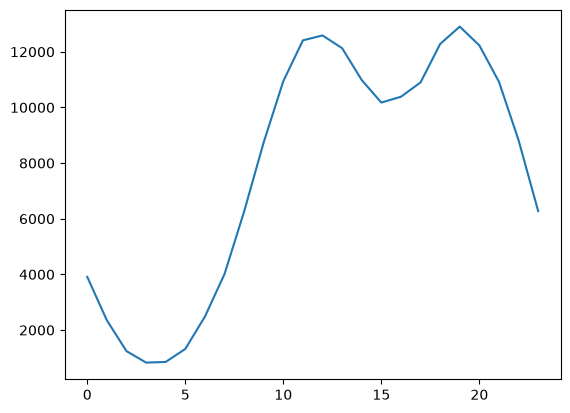

In [159]:
# Plot the line chart (we can pass any column for the Y-axis since .count() just counted the rows)
plt.plot(hours, results['Quantity Ordered'])

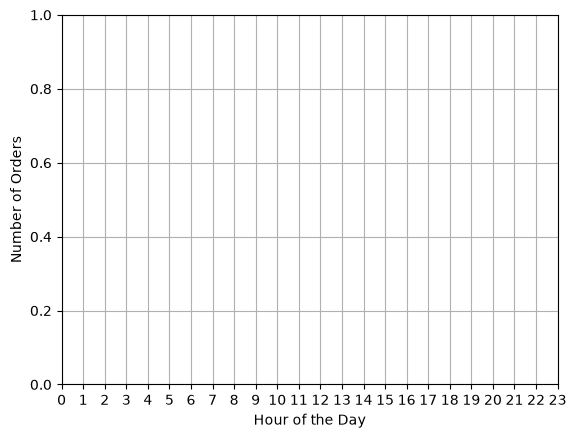

In [160]:
# Format the chart
plt.xticks(hours)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.grid() # Adds a helpful grid to the background

plt.show()

## Concept 1: Finding Duplicated Order IDs
How do we know if two items were bought at the exact same time? They will share the exact same Order ID
Therefore, the first step is to filter our massive dataset down to only the rows where the Order ID is duplicated.

In [161]:
# Create a new dataframe keeping ONLY rows with a duplicated Order ID
df = all_data[all_data['Order ID'].duplicated(keep=False)]

## Concept 2: Grouping Products into a Single String
Right now, the products bought together are on separate rows. We want to combine them onto a single line inside a new column called Grouped

In [162]:
# Group by Order ID and join the product strings with a comma
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))

## Concept 3: Dropping Redundant Rows
As you can see in the table above, we achieved our goal of grouping the items, but now we have duplicate rows holding the exact same grouped string
We need to strip this down so we only have one unique order per row

In [163]:
# Keep only the two columns we care about and drop the duplicate rows
df = df[['Order ID', 'Grouped']].drop_duplicates()

## Concept 4: Counting the Pairs
Now we have a clean list of grouped items, but we need to actually count which pairs appear most frequently. Because some orders might have 3 or 4 items combined together, we use Python's built-in itertools and collections libraries to help us cleanly isolate and count every possible pair of 2

In [164]:
from itertools import combinations
from collections import Counter

# Create a Counter object
count = Counter()

# Loop through every row in our Grouped column
for row in df['Grouped']:
    # Split the string back into a list
    row_list = row.split(',')
    # Update the counter with combinations of 2
    count.update(Counter(combinations(row_list, 2)))

# Print the 10 most common pairs
for key, value in count.most_common(10):
    print(key, value)

('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92


## Concept 1: Finding the Most Sold Product
To find out what sold the most, we simply group our data by the Product column. Instead of summing up the total sales in dollars, we want to sum up the Quantity Ordered

In [166]:
# Group by the Product column
product_group = all_data.groupby('Product')

In [169]:
# Calculate the sum for each product's quantity
quantity_ordered = product_group['Quantity Ordered'].sum()

## Concept 2: Forming a Hypothesis
By looking at our numbers (or plotting them on a standard bar chart), we can clearly see that AAA Batteries (4-pack) sold the most
.
As a data scientist, you must ask why. When you look at the top-selling items (batteries, charging cables, wired headphones) compared to the lowest-selling items (LG Dryers, Washing Machines), a clear hypothesis emerges: The top items sell the most because they are cheap

## Concept 3: Proving the Hypothesis
To prove this to the business, we need to compare the quantity ordered against the actual price of the items. First, we need to find the average price of each product. We do this by grouping by the product again, but this time using the .mean() method on the Price Each column


In [172]:
# Find the average price of each product
prices = all_data.groupby('Product')['Price Each'].mean()

### Now we have our prices, but how do we visualize this? If we put the price (e.g., $2.99 for batteries) on the exact same chart as the quantity (e.g., 31,000+ batteries), the price line will be completely invisible because the scale of the numbers is so incredibly different
.
### The Solution: We must create a chart with a secondary Y-axis
This allows the left side of the chart to measure the high numbers of the quantity, while the right side of the chart measures the lower values of the price, but both lines share the same products on the X-axis at the bottom

/tmp/ipykernel_7821/3856465726.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(products, rotation='vertical', size=8)


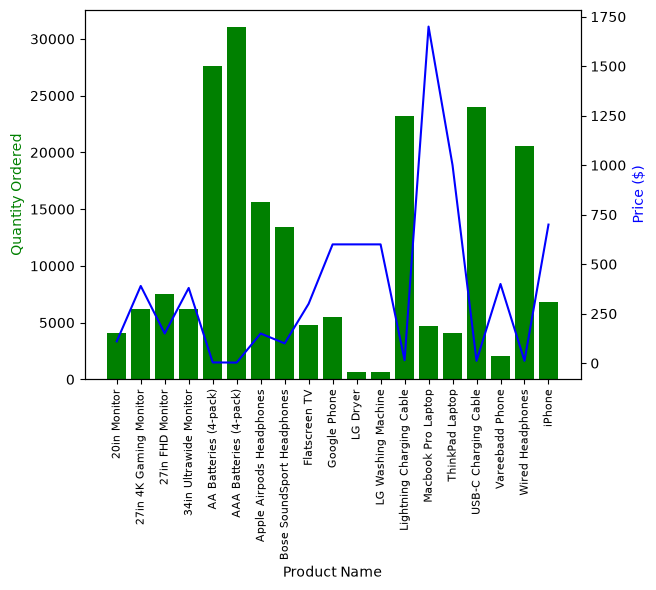

In [173]:
import matplotlib.pyplot as plt

# Grab the unique product names for our X-axis safely
products = [product for product, df in product_group]

# Set up the dual-axis chart (the creator adapted this from Stack Overflow!)
fig, ax1 = plt.subplots()
ax2 = ax1.twinx() # This creates a second Y-axis sharing the same X-axis

# Plot the bar chart (Quantity) on the first axis in green
ax1.bar(products, quantity_ordered, color='green')

# Plot the line chart (Price) on the second axis in blue
ax2.plot(products, prices, color='blue')

# Add labels and formatting
ax1.set_xlabel('Product Name')
ax1.set_ylabel('Quantity Ordered', color='green')
ax2.set_ylabel('Price ($)', color='blue')
ax1.set_xticklabels(products, rotation='vertical', size=8)

plt.show()